In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image

# Dataset used for training: FoodSeg103 

## Structure

`data/raw/foodseg103`:

  - `category_id.txt`: Numerical ID of each ingredient. encoded in grayscale mask of the image(*rgb(id,id,id)*)
  - `ImageSets/`:
    - `train.txt`: filenames of train batch images
    - `test.txt`: filenames of test batch images
  - `Images/`:
    - `ann_dir/`: masked images
    - `img_dir/`: clear images
        

## Example

### Ingredients list:

In [ ]:
# read ingredient mappings
with open(datasetPath + "category_id.txt", "r") as category_id:
    ingredients = [' '.join(line.strip().split()[1:]) for line in category_id.readlines()]


### Sample showcase:

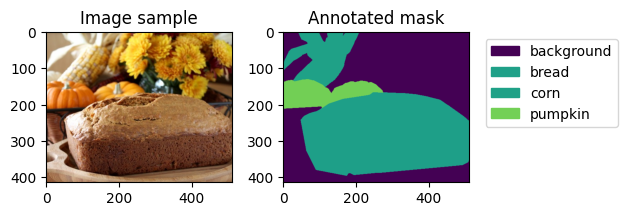

In [ ]:
CMAP="viridis" #gray

# read train image mappings
datasetPath = "../data/raw/foodseg103/"
with open(datasetPath + "ImageSets/train.txt", "r") as train_map:
    lines = train_map.readlines()
    imgFilename = np.random.choice(lines).strip()[:-4]

# load images
img = np.array(Image.open(datasetPath + "Images/img_dir/train/" + imgFilename + ".jpg")) 
ann = np.array(Image.open(datasetPath + "Images/ann_dir/train/" + imgFilename + ".png"))

# mark legend
imageIngredients = np.unique(ann)
cmap = plt.get_cmap(CMAP)
patches = [ 
    mpatches.Patch(color=cmap(i/(len(ingredients)-1)), label=ingredients[i])
    for i in imageIngredients
]

# plot the images
fig, ax = plt.subplots(ncols=2)
ax[0].set_title("Image sample")
ax[0].imshow(img)
ax[1].set_title("Annotated mask")
ax[1].imshow(ann, cmap=CMAP, vmin=0, vmax=len(ingredients)-1)
ax[1].legend(handles=patches, loc="upper left", bbox_to_anchor=(1.05, 1))
plt.tight_layout()